# EEG_00_labels_and_tasks

Questo notebook crea **etichette alternative** per le 110 parole del dataset.
L'idea è non fermarsi a uno schema solo, ma confrontare più approcci e poi scegliere quello più sensato per il training EEG.

## Perché non basta il clustering manuale

Sì, esistono approcci più rigorosi. Il problema del clustering manuale è che introduce **bias del ricercatore**: sei tu a decidere le categorie, non i dati.

## Approcci che mettiamo nel file

### 1) Ward su embeddings semantici
È già un approccio automatico. Però se la silhouette preferisce `k=2`, vuol dire che forzare 4 o 5 cluster potrebbe non riflettere una vera struttura naturale nello spazio semantico.

### 2) Norme psicolinguistiche
Approccio standard in neuroscienza cognitiva. L'idea è usare rating empirici come:
- concreteness / abstractness
- imageability
- valence / arousal
- eventuali norme sensorimotorie

Qui il clustering non nasce da categorie inventate a mano, ma da misure raccolte sperimentalmente. Nel notebook lasciamo una sezione pronta, così se aggiungi un file `.csv` con queste norme puoi generare cluster in modo riproducibile.

### 3) EEG-driven clustering
È l'approccio più interessante per la tesi BCI.
Invece di partire dal significato linguistico, parti dal segnale EEG:
- fai il prototipo medio per ogni parola
- fai clustering nello spazio EEG
- vedi se emergono gruppi interpretabili

In questo modo **le categorie emergono dai dati cerebrali**.

### 4) Manuale, ma solo come baseline
Teniamo anche gli schemi manuali POS e Semantico-BCI.
Non perché siano i più rigorosi, ma perché sono interpretabili e utili come confronto.

## Strategia finale
Nel notebook:
1. generiamo più mapping
2. li valutiamo con metriche interne
3. confrontiamo interpretabilità e utilità pratica
4. poi decidiamo quale portare nel training principale

Output in `data/interim/`:
- `idx2label.json`
- `word2cluster_4.json` / `labelid2cluster_4.json`
- `word2cluster_5.json` / `labelid2cluster_5.json`
- `word2cluster_pos4.json` / `labelid2cluster_pos4.json`
- `word2cluster_sem5.json` / `labelid2cluster_sem5.json`
- opzionali: `word2cluster_psycho_*.json`, `word2cluster_eeg_*.json`

Data: 2026-03-12


In [1]:
from pathlib import Path
import os, json, gc, warnings
import numpy as np
import pandas as pd
from collections import defaultdict

# evita warning/tokenizers fork
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=FutureWarning)

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
interim_dir = project_root / "data" / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)

label2idx_path = interim_dir / "label2idx.json"
assert label2idx_path.exists(), f"Missing {label2idx_path}"

with open(label2idx_path, "r", encoding="utf-8") as f:
    label2idx = json.load(f)

label2idx = {str(k): int(v) for k, v in label2idx.items()}
idx2label = {int(v): str(k) for k, v in label2idx.items()}

# lista parole in ordine di label_id
true_labels = [idx2label[i] for i in sorted(idx2label.keys())]

print("num labels:", len(true_labels))
print("first 10:", true_labels[:10])

# salva idx2label comodo
idx2label_path = interim_dir / "idx2label.json"
with open(idx2label_path, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in idx2label.items()}, f, ensure_ascii=False, indent=2)
print("saved:", idx2label_path)

# config anti-crash
FAST_MODE = True
RANDOM_STATE = 42
MAX_K = 8 if FAST_MODE else 10
ANNOTATE_EVERY = 10 if FAST_MODE else 6


num labels: 110
first 10: ['accendere', 'acqua', 'adesso', 'aiuto', 'amore', 'anche', 'andare', 'anno', 'ansia', 'aprire']
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/idx2label.json


## Install (una volta sola nell’ambiente)
Se ti mancano librerie, scommenta e runna.


In [2]:
# !pip install -q sentence-transformers scipy scikit-learn


In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# NB: SentenceTransformer NON viene importato qui per evitare di caricare
# PyTorch (molto pesante in RAM) quando gli embedding sono già in cache.
# Viene importato on-demand nella cella successiva solo se necessario.


## 1) Embeddings semantici


In [4]:
import sys

MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

# --- Cache degli embedding su disco ---
# Su macchine con poca RAM (~3-4 GB liberi su 16 GB), caricare
# SentenceTransformer + PyTorch può causare crash nelle celle successive.
# Soluzione: calcoliamo gli embedding UNA SOLA VOLTA e li salviamo su .npy.
# Nelle esecuzioni successive PyTorch non viene mai caricato.
emb_cache_path = interim_dir / f"emb_cache_{MODEL_NAME.replace('/', '_')}.npy"

if emb_cache_path.exists():
    print(f"Cache trovata: {emb_cache_path}")
    emb = np.load(emb_cache_path)
    print("Embedding caricati da cache (PyTorch NON è stato caricato in memoria).")
else:
    print("Cache non trovata. Caricamento modello SentenceTransformer...")
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_NAME, device="cpu")  # CPU: evita crash MPS

    emb = model.encode(
        true_labels,
        normalize_embeddings=True,
        show_progress_bar=False,
        batch_size=16,
        convert_to_numpy=True,
    )
    emb = np.asarray(emb, dtype=np.float32)
    np.save(emb_cache_path, emb)
    print(f"Cache salvata: {emb_cache_path}")

    del model
    gc.collect()
    print("Memoria SentenceTransformer liberata.")

print("emb shape:", emb.shape)
print("emb dtype:", emb.dtype)


Cache trovata: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/emb_cache_paraphrase-multilingual-MiniLM-L12-v2.npy
Embedding caricati da cache (PyTorch NON è stato caricato in memoria).
emb shape: (110, 384)
emb dtype: float32


## 2) Clustering gerarchico + dendrogram (Ward)


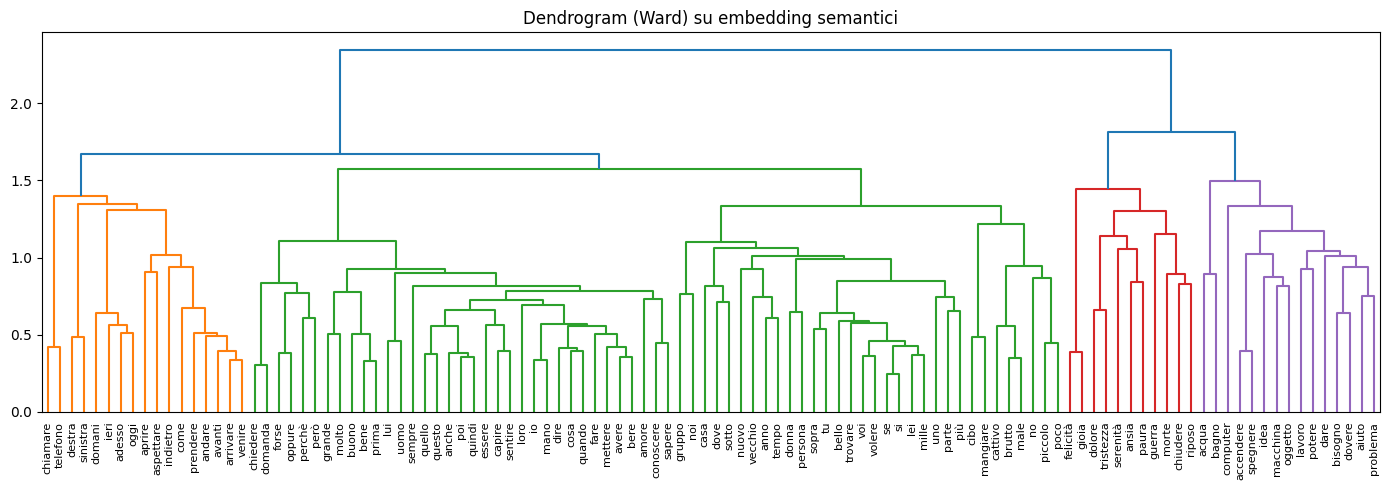

In [5]:
Z = linkage(emb, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, labels=true_labels, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram (Ward) su embedding semantici")
plt.tight_layout()
plt.show()
plt.close()


## 3) Ward automatico a 4 cluster

Qui teniamo il clustering gerarchico automatico come baseline semantica.


In [6]:
cluster_ids_4 = fcluster(Z, t=4, criterion="maxclust")  # 1..4
cluster_ids_4 = cluster_ids_4 - 1                       # 0..3

cluster2words_4 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_4):
    cluster2words_4[int(c)].append(w)

print("=== CLUSTER A 4 CLASSI ===")
for c in sorted(cluster2words_4.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_4[c]))

word2cluster_4 = {w: int(c) for w, c in zip(true_labels, cluster_ids_4)}
out_word2c4 = interim_dir / "word2cluster_4.json"
with open(out_word2c4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_4, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c4}")


=== CLUSTER A 4 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
amore, anche, anno, avere, bello, bene, bere, brutto, buono, capire, casa, cattivo, chiedere, cibo, conoscere, cosa, dire, domanda, donna, dove, essere, fare, forse, grande, gruppo, io, lei, loro, lui, male, mangiare, mano, mettere, mille, molto, no, noi, nuovo, oppure, parte, perchè, persona, però, piccolo, più, poco, poi, prima, quando, quello, questo, quindi, sapere, se, sempre, sentire, si, sopra, sotto, tempo, trovare, tu, uno, uomo, vecchio, voi, volere

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

Saved semantic cluster mapping to /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-s

## 4) 5 cluster: split SOLO del cluster più grande in 2 sottocluster (k=2)


In [7]:
# trova cluster più grande
sizes = {c: len(ws) for c, ws in cluster2words_4.items()}
big_c = max(sizes, key=sizes.get)
print("largest cluster (from 4):", big_c, "size:", sizes[big_c])

idx_big = [i for i, c in enumerate(cluster_ids_4) if int(c) == int(big_c)]
emb_big = emb[idx_big]

km_sub = KMeans(n_clusters=2, random_state=42, n_init=10)
sub_ids = km_sub.fit_predict(emb_big)  # 0/1

new_cluster_ids = np.array(cluster_ids_4, dtype=int)  # start from 0..3
new_id = 4

for j, i_word in enumerate(idx_big):
    if int(sub_ids[j]) == 0:
        new_cluster_ids[i_word] = int(big_c)
    else:
        new_cluster_ids[i_word] = new_id

# ricompatta per avere 0..4 sempre
uniq = sorted(np.unique(new_cluster_ids).tolist())
remap = {old: new for new, old in enumerate(uniq)}
cluster_ids_5 = np.array([remap[int(c)] for c in new_cluster_ids], dtype=int)

cluster2words_5 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_5):
    cluster2words_5[int(c)].append(w)

print("\n=== CLUSTER FINALI A 5 CLASSI ===")
for c in sorted(cluster2words_5.keys()):
    print(f"\nCLUSTER {c}:")
    print(", ".join(cluster2words_5[c]))

word2cluster_5 = {w: int(c) for w, c in zip(true_labels, cluster_ids_5)}
out_word2c5 = interim_dir / "word2cluster_5.json"
with open(out_word2c5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_5, f, ensure_ascii=False, indent=2)
print(f"\nSaved semantic cluster mapping to {out_word2c5}")


largest cluster (from 4): 1 size: 67

=== CLUSTER FINALI A 5 CLASSI ===

CLUSTER 0:
adesso, andare, aprire, arrivare, aspettare, avanti, chiamare, come, destra, domani, ieri, indietro, oggi, prendere, sinistra, telefono, venire

CLUSTER 1:
anno, bello, brutto, casa, cattivo, cibo, donna, dove, fare, grande, gruppo, lei, male, mangiare, mille, no, nuovo, parte, persona, piccolo, più, poco, se, sopra, sotto, tempo, trovare, uno, uomo, vecchio, voi

CLUSTER 2:
ansia, chiudere, dolore, felicità, gioia, guerra, morte, paura, riposo, serenità, tristezza

CLUSTER 3:
accendere, acqua, aiuto, bagno, bisogno, computer, dare, dovere, idea, lavoro, macchina, oggetto, potere, problema, spegnere

CLUSTER 4:
amore, anche, avere, bene, bere, buono, capire, chiedere, conoscere, cosa, dire, domanda, essere, forse, io, loro, lui, mano, mettere, molto, noi, oppure, perchè, però, poi, prima, quando, quello, questo, quindi, sapere, sempre, sentire, si, tu, volere

Saved semantic cluster mapping to /Users/da

## 5) label_id -> cluster_id (per training)


In [8]:
labelid2cluster_4 = {int(label2idx[w]): int(word2cluster_4[w]) for w in true_labels}
labelid2cluster_5 = {int(label2idx[w]): int(word2cluster_5[w]) for w in true_labels}

out_l2c4 = interim_dir / "labelid2cluster_4.json"
out_l2c5 = interim_dir / "labelid2cluster_5.json"

with open(out_l2c4, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_4.items()}, f, ensure_ascii=False, indent=2)
with open(out_l2c5, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_5.items()}, f, ensure_ascii=False, indent=2)

print("saved:", out_l2c4)
print("saved:", out_l2c5)

print("\nEsempio mapping (prime 10 parole):")
for w in true_labels[:10]:
    print(w, "->", word2cluster_5[w])


saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_4.json
saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_5.json

Esempio mapping (prime 10 parole):
accendere -> 3
acqua -> 3
adesso -> 0
aiuto -> 3
amore -> 4
anche -> 4
andare -> 0
anno -> 1
ansia -> 2
aprire -> 0


## 6) Helper: rimappa y (label_id) in cluster_id


In [9]:
def remap_y_to_clusters(y, labelid2cluster):
    y = np.asarray(y, dtype=int)
    return np.array([labelid2cluster[int(v)] for v in y], dtype=int)

# esempio:
# with open(interim_dir/'labelid2cluster_5.json','r') as f: m = {int(k):int(v) for k,v in json.load(f).items()}
# y_cluster5 = remap_y_to_clusters(y_epochs, m)


---

## 7) Scelta di k e metriche interne

Questa parte era una delle cause del crash:
- `n_init=30` dentro il loop
- più plot nello stesso blocco
- memoria non liberata

Qui facciamo una versione più leggera.


,k,silhouette,davies_bouldin,inertia
0,2,0.109936,3.480312,36.693512
1,3,0.091931,3.197750,34.941605
2,4,0.047877,2.912969,33.523884
3,5,0.056112,2.579547,32.329880
4,6,0.052276,2.443230,31.445950
5,7,0.062689,2.663009,30.639011
6,8,0.096583,2.227733,29.781384


k ottimale per silhouette: 2


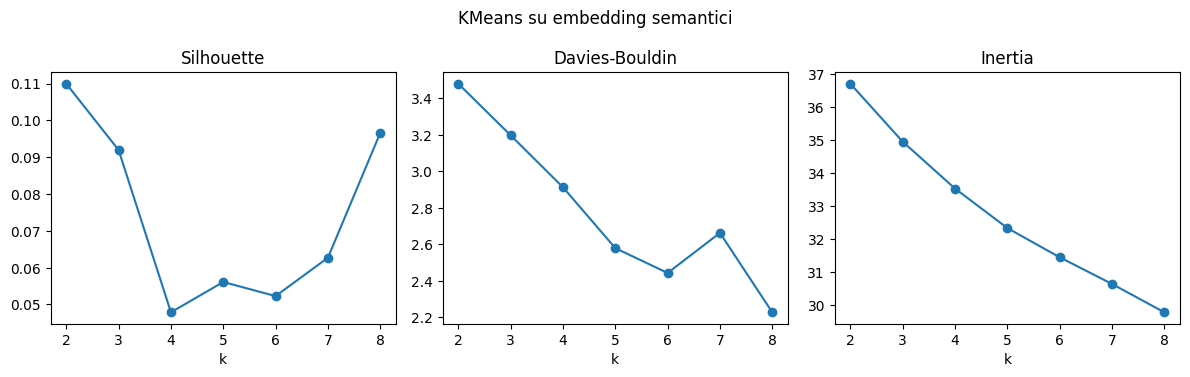

In [10]:
k_range = list(range(2, MAX_K + 1))
metrics = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(emb)
    metrics.append({
        "k": k,
        "silhouette": float(silhouette_score(emb, labels_k)),
        "davies_bouldin": float(davies_bouldin_score(emb, labels_k)),
        "inertia": float(km.inertia_),
    })

df_m = pd.DataFrame(metrics)
display(df_m)

best_k = int(df_m.loc[df_m["silhouette"].idxmax(), "k"])
print(f"k ottimale per silhouette: {best_k}")

fig = plt.figure(figsize=(12, 3.8))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.plot(df_m["k"], df_m["silhouette"], marker="o")
ax1.set_title("Silhouette")
ax1.set_xlabel("k")

ax2.plot(df_m["k"], df_m["davies_bouldin"], marker="o")
ax2.set_title("Davies-Bouldin")
ax2.set_xlabel("k")

ax3.plot(df_m["k"], df_m["inertia"], marker="o")
ax3.set_title("Inertia")
ax3.set_xlabel("k")

plt.suptitle("KMeans su embedding semantici")
plt.tight_layout()
plt.show()
plt.close()


---

## 8) Schema POS — 4 classi grammaticali (manuale)

Classificazione basata sulla **parte del discorso** (Part-of-Speech) italiana.  
È lo schema più rigido linguisticamente: ogni parola appartiene a una sola categoria grammaticale.

| Classe | Descrizione | Esempi |
|--------|-------------|--------|
| **VERBI** | Verbi all'infinito presente | andare, fare, sentire |
| **SOSTANTIVI** | Sostantivi concreti e astratti | casa, dolore, idea |
| **MODIFICATORI** | Aggettivi e avverbi con contenuto lessicale | bello, sempre, piccolo |
| **GRAMMATICALI** | Pronomi, congiunzioni, particelle | io, perchè, oppure |

> Questa classificazione è **indipendente dagli embedding**: non usa affatto il modello SBERT.


In [11]:
# Schema POS: 4 classi grammaticali italiane
manual_pos = {
    "VERBI": [
        # tutti verbi all'infinito presente — azioni fisiche, cognitive, modali
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "SOSTANTIVI": [
        # nomi concreti e astratti — oggetti, luoghi, stati, concetti
        "acqua", "aiuto", "amore", "anno", "ansia", "bagno", "bisogno",
        "casa", "cibo", "computer", "dolore", "domanda", "donna", "felicità",
        "gioia", "gruppo", "guerra", "idea", "lavoro", "macchina", "mano",
        "mille", "morte", "oggetto", "paura", "parte", "persona", "problema",
        "riposo", "serenità", "telefono", "tempo", "tristezza", "uomo"
    ],
    "MODIFICATORI": [
        # aggettivi e avverbi con significato lessicale autonomo
        "adesso", "avanti", "bello", "bene", "brutto", "buono", "cattivo",
        "destra", "domani", "grande", "ieri", "indietro", "male", "molto",
        "nuovo", "oggi", "piccolo", "più", "poco", "poi", "prima",
        "sempre", "sinistra", "sopra", "sotto", "vecchio"
    ],
    "GRAMMATICALI": [
        # pronomi personali, congiunzioni, particelle, numerali, deittici
        "anche", "come", "cosa", "dove", "forse", "io", "lei", "loro",
        "lui", "no", "noi", "oppure", "perchè", "però", "quando",
        "quello", "questo", "quindi", "se", "si", "tu", "uno", "voi"
    ]
}

# --- validazione: ogni parola del dataset deve apparire esattamente una volta ---
all_assigned_pos = [w for ws in manual_pos.values() for w in ws]
missing_pos  = set(true_labels) - set(all_assigned_pos)
extra_pos    = set(all_assigned_pos) - set(true_labels)
dupl_pos     = {w for w in all_assigned_pos if all_assigned_pos.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_pos)}")
print(f"Mancanti dal dataset: {missing_pos or '—'}")
print(f"Parole extra (non nel dataset): {extra_pos or '—'}")
print(f"Duplicati: {dupl_pos or '—'}")

print("\n=== SCHEMA POS — 4 CLASSI ===")
for cat, words in manual_pos.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


Dataset: 110 parole | Assegnate: 110
Mancanti dal dataset: —
Parole extra (non nel dataset): —
Duplicati: —

=== SCHEMA POS — 4 CLASSI ===

VERBI (27):
accendere, andare, aprire, arrivare, aspettare, avere, bere, capire, chiamare, chiedere, chiudere, conoscere, dare, dire, dovere, essere, fare, mangiare, mettere, potere, prendere, sapere, sentire, spegnere, trovare, venire, volere

SOSTANTIVI (34):
acqua, aiuto, amore, anno, ansia, bagno, bisogno, casa, cibo, computer, dolore, domanda, donna, felicità, gioia, gruppo, guerra, idea, lavoro, macchina, mano, mille, morte, oggetto, parte, paura, persona, problema, riposo, serenità, telefono, tempo, tristezza, uomo

MODIFICATORI (26):
adesso, avanti, bello, bene, brutto, buono, cattivo, destra, domani, grande, ieri, indietro, male, molto, nuovo, oggi, piccolo, più, poco, poi, prima, sempre, sinistra, sopra, sotto, vecchio

GRAMMATICALI (23):
anche, come, cosa, dove, forse, io, lei, loro, lui, no, noi, oppure, perchè, però, quando, quello, qu

In [12]:
# Costruzione mapping e salvataggio schema POS-4
cat_names_pos4 = list(manual_pos.keys())

word2cluster_pos4 = {}
for cat_id, (cat_name, words) in enumerate(manual_pos.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_pos4[w] = cat_id

# catch-all per eventuali parole non coperte dallo schema
for w in true_labels:
    if w not in word2cluster_pos4:
        print(f"ATTENZIONE: '{w}' non assegnata → assegnata a GRAMMATICALI (3)")
        word2cluster_pos4[w] = 3

labelid2cluster_pos4 = {int(label2idx[w]): int(word2cluster_pos4[w]) for w in true_labels}

out_pos4      = interim_dir / "word2cluster_pos4.json"
out_pos4_lid  = interim_dir / "labelid2cluster_pos4.json"
out_pos4_names = interim_dir / "cluster_names_pos4.json"

with open(out_pos4, "w", encoding="utf-8") as f:
    json.dump(word2cluster_pos4, f, ensure_ascii=False, indent=2)
with open(out_pos4_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_pos4.items()}, f, ensure_ascii=False, indent=2)
with open(out_pos4_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_pos4)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_pos4}")
print(f"Saved: {out_pos4_lid}")
print(f"Saved: {out_pos4_names}")
print("\nDistribuzione classi POS-4:")
for cat_id, cat_name in enumerate(cat_names_pos4):
    count = sum(1 for v in word2cluster_pos4.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:15s}: {count:3d} parole  {'█' * count}")


Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/word2cluster_pos4.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_pos4.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/cluster_names_pos4.json

Distribuzione classi POS-4:
  0 — VERBI          :  27 parole  ███████████████████████████
  1 — SOSTANTIVI     :  34 parole  ██████████████████████████████████
  2 — MODIFICATORI   :  26 parole  ██████████████████████████
  3 — GRAMMATICALI   :  23 parole  ███████████████████████


---

## 9) Schema Semantico-BCI — 5 classi (manuale)

Classificazione basata su **categorie semantiche rilevanti per l'EEG e il BCI**.  
Ogni classe è associata a un substrato neurale diverso, il che motiva la scelta per il decoding.

| Classe | Substrato neurale atteso | Descrizione |
|--------|--------------------------|-------------|
| **AZIONI** | Corteccia motoria/premotoria (imagery motoria) | Tutti i verbi all'infinito |
| **EMOZIONI_VALENZA** | Sistema limbico, amigdala, corteccia orbito-frontale | Emozioni + aggettivi valutativi |
| **OGGETTI_PERSONE** | Corteccia temporale inferiore (riconoscimento oggetti) | Sostantivi concreti, fisici |
| **CONCETTI_ASTRATTI** | Corteccia prefrontale, temporale superiore | Sostantivi astratti, situazioni |
| **PAROLE_FUNZIONE** | Aree linguistiche (Broca/Wernicke), rete del default mode | Pronomi, congiunzioni, deittici, quantificatori |

> **Motivazione**: rispetto al Ward gerarchico, questa classificazione evita cluster incoerenti  
> (es. il vecchio CLUSTER 1 con 67 parole eterogenee) e permette interpretazioni neurologiche dirette.


In [13]:
# Schema Semantico-BCI: 5 classi neuroscientificamente motivate
manual_sem5 = {
    "AZIONI": [
        # tutti i verbi all'infinito (imagery motoria, action planning)
        "accendere", "andare", "aprire", "arrivare", "aspettare", "avere",
        "bere", "capire", "chiamare", "chiedere", "chiudere", "conoscere",
        "dare", "dire", "dovere", "essere", "fare", "mangiare", "mettere",
        "potere", "prendere", "sapere", "sentire", "spegnere", "trovare",
        "venire", "volere"
    ],
    "EMOZIONI_VALENZA": [
        # stati emotivi e aggettivi con valenza affettiva forte (sistema limbico)
        "amore", "ansia", "bello", "bene", "brutto", "buono", "cattivo",
        "dolore", "felicità", "gioia", "guerra", "male", "morte",
        "paura", "riposo", "serenità", "tristezza"
    ],
    "OGGETTI_PERSONE": [
        # referenti concreti fisicamente immaginabili: oggetti, luoghi, persone
        "acqua", "aiuto", "bagno", "casa", "cibo", "computer", "donna",
        "gruppo", "macchina", "mano", "oggetto", "persona", "telefono", "uomo"
    ],
    "CONCETTI_ASTRATTI": [
        # sostantivi astratti: concetti, situazioni, relazioni senza referente fisico
        "anno", "bisogno", "domanda", "idea", "lavoro", "mille",
        "parte", "problema", "tempo"
    ],
    "PAROLE_FUNZIONE": [
        # pronomi personali, congiunzioni, avverbi, deittici spaziali/temporali, quantificatori
        "adesso", "anche", "avanti", "come", "cosa", "destra", "domani",
        "dove", "forse", "grande", "ieri", "indietro", "io", "lei", "loro",
        "lui", "molto", "noi", "no", "nuovo", "oggi", "oppure", "perchè",
        "però", "piccolo", "più", "poco", "poi", "prima", "quando",
        "quello", "questo", "quindi", "se", "sempre", "sinistra", "si",
        "sopra", "sotto", "tu", "uno", "vecchio", "voi"
    ]
}

# --- validazione ---
all_assigned_sem = [w for ws in manual_sem5.values() for w in ws]
missing_sem  = set(true_labels) - set(all_assigned_sem)
extra_sem    = set(all_assigned_sem) - set(true_labels)
dupl_sem     = {w for w in all_assigned_sem if all_assigned_sem.count(w) > 1}

print(f"Dataset: {len(true_labels)} parole | Assegnate: {len(all_assigned_sem)}")
print(f"Mancanti: {missing_sem or '—'}")
print(f"Extra: {extra_sem or '—'}")
print(f"Duplicati: {dupl_sem or '—'}")

print("\n=== SCHEMA SEMANTICO-BCI — 5 CLASSI ===")
for cat, words in manual_sem5.items():
    print(f"\n{cat} ({len(words)}):")
    print(", ".join(sorted(words)))


Dataset: 110 parole | Assegnate: 110
Mancanti: —
Extra: —
Duplicati: —

=== SCHEMA SEMANTICO-BCI — 5 CLASSI ===

AZIONI (27):
accendere, andare, aprire, arrivare, aspettare, avere, bere, capire, chiamare, chiedere, chiudere, conoscere, dare, dire, dovere, essere, fare, mangiare, mettere, potere, prendere, sapere, sentire, spegnere, trovare, venire, volere

EMOZIONI_VALENZA (17):
amore, ansia, bello, bene, brutto, buono, cattivo, dolore, felicità, gioia, guerra, male, morte, paura, riposo, serenità, tristezza

OGGETTI_PERSONE (14):
acqua, aiuto, bagno, casa, cibo, computer, donna, gruppo, macchina, mano, oggetto, persona, telefono, uomo

CONCETTI_ASTRATTI (9):
anno, bisogno, domanda, idea, lavoro, mille, parte, problema, tempo

PAROLE_FUNZIONE (43):
adesso, anche, avanti, come, cosa, destra, domani, dove, forse, grande, ieri, indietro, io, lei, loro, lui, molto, no, noi, nuovo, oggi, oppure, perchè, però, piccolo, più, poco, poi, prima, quando, quello, questo, quindi, se, sempre, si, si

In [14]:
# Costruzione mapping e salvataggio schema Semantico-BCI 5
cat_names_sem5 = list(manual_sem5.keys())

word2cluster_sem5 = {}
for cat_id, (cat_name, words) in enumerate(manual_sem5.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_sem5[w] = cat_id

# catch-all
for w in true_labels:
    if w not in word2cluster_sem5:
        print(f"ATTENZIONE: '{w}' non assegnata → PAROLE_FUNZIONE (4)")
        word2cluster_sem5[w] = 4

labelid2cluster_sem5 = {int(label2idx[w]): int(word2cluster_sem5[w]) for w in true_labels}

out_sem5       = interim_dir / "word2cluster_sem5.json"
out_sem5_lid   = interim_dir / "labelid2cluster_sem5.json"
out_sem5_names = interim_dir / "cluster_names_sem5.json"

with open(out_sem5, "w", encoding="utf-8") as f:
    json.dump(word2cluster_sem5, f, ensure_ascii=False, indent=2)
with open(out_sem5_lid, "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in labelid2cluster_sem5.items()}, f, ensure_ascii=False, indent=2)
with open(out_sem5_names, "w", encoding="utf-8") as f:
    json.dump({str(i): name for i, name in enumerate(cat_names_sem5)}, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_sem5}")
print(f"Saved: {out_sem5_lid}")
print(f"Saved: {out_sem5_names}")
print("\nDistribuzione classi Semantico-BCI-5:")
for cat_id, cat_name in enumerate(cat_names_sem5):
    count = sum(1 for v in word2cluster_sem5.values() if v == cat_id)
    print(f"  {cat_id} — {cat_name:22s}: {count:3d} parole  {'█' * count}")


Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/word2cluster_sem5.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/labelid2cluster_sem5.json
Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/interim/cluster_names_sem5.json

Distribuzione classi Semantico-BCI-5:
  0 — AZIONI                :  27 parole  ███████████████████████████
  1 — EMOZIONI_VALENZA      :  17 parole  █████████████████
  2 — OGGETTI_PERSONE       :  14 parole  ██████████████
  3 — CONCETTI_ASTRATTI     :   9 parole  █████████
  4 — PAROLE_FUNZIONE       :  43 parole  ███████████████████████████████████████████


---
## Nuovi Schemi Word-Based

Le seguenti tecniche usano **solo le parole** (non le feature EEG) per costruire i cluster target.
Motivazione: l'analisi RSA (r=0.001) e ARI cross-subject (≈0) mostrano che i cluster EEG-driven
non sono affidabili. Solo gli schemi word-based producono label stabili e replicabili.

| Schema | k | Tipo | Motivazione |
|--------|---|------|-------------|
| `ward6` | 6 | Auto (Ward su SBERT) | Più fine-grained del corrente ward4/ward5 |
| `concr4` | 4 | Manuale (Concreteness) | Concreto/Azione/Stato/Astratto — basi neurolinguistiche solide |
| `phon4` | 4 | Regola (Onset fonologico) | VOC/LAB/COR/DOR — rilevante per motor speech planning |

In [ ]:
# ── Ward-6: clustering gerarchico su SBERT con k=6 ────────────────────────────
# Riusa Z (dendrogramma già calcolato in cella 8) e emb (embedding SBERT)
# Non richiede annotazione manuale — più fine-grained di ward4/ward5

from scipy.cluster.hierarchy import fcluster

cluster_ids_6 = fcluster(Z, t=6, criterion="maxclust") - 1  # 0..5
word2cluster_ward6  = {w: int(c) for w, c in zip(true_labels, cluster_ids_6)}
labelid2cluster_ward6 = {int(label2idx[w]): int(word2cluster_ward6[w]) for w in true_labels}

cluster2words_ward6 = {}
for w, c in word2cluster_ward6.items():
    cluster2words_ward6.setdefault(c, []).append(w)

# nomi automatici dal primo triplo di parole per cluster
cat_names_ward6 = [
    f"W6_C{c}({','.join(sorted(cluster2words_ward6.get(c, []))[:2])})"
    for c in range(6)
]

# salvataggio
with open(interim_dir / "word2cluster_ward6.json", "w", encoding="utf-8") as f:
    json.dump(word2cluster_ward6, f, ensure_ascii=False, indent=2)
with open(interim_dir / "labelid2cluster_ward6.json", "w", encoding="utf-8") as f:
    json.dump(labelid2cluster_ward6, f, ensure_ascii=False, indent=2)
with open(interim_dir / "cluster_names_ward6.json", "w", encoding="utf-8") as f:
    json.dump({str(i): n for i, n in enumerate(cat_names_ward6)}, f, ensure_ascii=False, indent=2)

sil_ward6 = silhouette_score(emb, cluster_ids_6)
print(f"Ward-6  |  silhouette SBERT: {sil_ward6:.4f}  (ward4={silhouette_score(emb, fcluster(Z,t=4,criterion='maxclust')-1):.4f})")
print("Composizione cluster:")
for c in range(6):
    words_c = sorted(cluster2words_ward6.get(c, []))
    print(f"  C{c} ({len(words_c)} parole): {', '.join(words_c)}")

In [ ]:
# ── Concreteness-4: 4 classi basate sulla concreteness linguistica ─────────────
#
# Motivazione neurolinguistica:
#   CONCR  : oggetti fisici, luoghi, persone — attivano cortex visivo/ventrale
#   AZIONE : verbi d'azione e processi cognitivi — attivano aree motorie/frontali
#   STATO  : emozioni, stati corporei, qualità valutative — attivano circuiti limbici
#   ASTRATTO: concetti relazionali, parole funzione, dittici spazio-temporali
#
# Riferimenti: Binder et al. (2011) JNeurosci; Vigliocco et al. (2014) PsychRev;
#              norme di concreteness italiane Montefinese et al. (2014)
#
# Distribuzione: CONCR=18, AZIONE=27, STATO=21, ASTRATTO=44  (tot=110)

concr4_manual = {
    "CONCR": [
        "acqua", "bagno", "casa", "cibo", "computer", "donna",
        "gruppo", "guerra", "idea", "lavoro", "macchina", "mano",
        "morte", "oggetto", "persona", "problema", "telefono", "uomo",
    ],
    "AZIONE": [
        "accendere", "andare", "aprire", "arrivare", "aspettare",
        "avere", "bere", "capire", "chiamare", "chiedere", "chiudere",
        "conoscere", "dare", "dire", "dovere", "essere", "fare",
        "mangiare", "mettere", "potere", "prendere", "sapere",
        "sentire", "spegnere", "trovare", "venire", "volere",
    ],
    "STATO": [
        "aiuto", "amore", "ansia", "bello", "bene", "bisogno",
        "brutto", "buono", "cattivo", "dolore", "felicità", "gioia",
        "grande", "male", "nuovo", "paura", "piccolo", "riposo",
        "serenità", "tristezza", "vecchio",
    ],
    "ASTRATTO": [
        "adesso", "anche", "anno", "avanti", "come", "cosa",
        "destra", "domanda", "domani", "dove", "forse", "ieri",
        "indietro", "io", "lei", "loro", "lui", "mille", "molto",
        "no", "noi", "oggi", "oppure", "parte", "perchè", "però",
        "più", "poco", "poi", "prima", "quando", "quello", "questo",
        "quindi", "se", "sempre", "si", "sinistra", "sopra", "sotto",
        "tempo", "tu", "uno", "voi",
    ],
}

cat_names_concr4 = list(concr4_manual.keys())
word2cluster_concr4 = {}
for cat_id, (cat_name, words) in enumerate(concr4_manual.items()):
    for w in words:
        if w in set(true_labels):
            word2cluster_concr4[w] = cat_id

# catch-all per parole non assegnate
for w in true_labels:
    if w not in word2cluster_concr4:
        print(f"ATTENZIONE: '{w}' non assegnata → ASTRATTO (3)")
        word2cluster_concr4[w] = 3

labelid2cluster_concr4 = {int(label2idx[w]): int(word2cluster_concr4[w]) for w in true_labels}

cluster2words_concr4 = {}
for w, c in word2cluster_concr4.items():
    cluster2words_concr4.setdefault(c, []).append(w)

# salvataggio
with open(interim_dir / "word2cluster_concr4.json", "w", encoding="utf-8") as f:
    json.dump(word2cluster_concr4, f, ensure_ascii=False, indent=2)
with open(interim_dir / "labelid2cluster_concr4.json", "w", encoding="utf-8") as f:
    json.dump(labelid2cluster_concr4, f, ensure_ascii=False, indent=2)
with open(interim_dir / "cluster_names_concr4.json", "w", encoding="utf-8") as f:
    json.dump({str(i): n for i, n in enumerate(cat_names_concr4)}, f, ensure_ascii=False, indent=2)

sil_concr4 = silhouette_score(emb, [word2cluster_concr4[w] for w in true_labels])
print(f"Concreteness-4  |  silhouette SBERT: {sil_concr4:.4f}")
print(f"Totale parole assegnate: {len(word2cluster_concr4)} / {len(true_labels)}")
print("Composizione cluster:")
for c, name in enumerate(cat_names_concr4):
    words_c = sorted(cluster2words_concr4.get(c, []))
    print(f"  {name} ({len(words_c)} parole): {', '.join(words_c)}")

In [ ]:
# ── Phonological-4: 4 classi per onset fonologico ────────────────────────────
#
# Motivazione: l'imagined speech attiva il sistema di pianificazione articolatoria.
# Il luogo di articolazione del primo fonema differenzia i pattern motori EEG.
#
#   VOC  (onset vocalico: a/e/i/o/u)        — nessuna ostruzione, n=24
#   LAB  (labiale: b/p/m/f/v)               — chiusura/costrizione labiale, n=35
#   COR  (coronale: d/t/s/l/n/r)            — lingua verso alveoli/denti, n=32
#   DOR  (dorsale/palatale: c/g/q/ch/gh)    — lingua verso palato/velo, n=19
#
# Regola applicata sistematicamente dal primo grafema italiano.
# Riferimento: Cooney et al. (2020) iScience — fonologia e aree motorie in imagined speech

def _phon_group(word: str) -> int:
    w = word.lower().strip()
    if not w:
        return 3
    if w[0] in "aeiouàèéìòóù":
        return 0   # VOC
    if w[0] in "bpmfv":
        return 1   # LAB
    if w[0] in "dtszlnr":
        return 2   # COR
    if w[0] in "cgq":
        return 3   # DOR
    return 2       # fallback coronale

phon_groups = ["VOC", "LAB", "COR", "DOR"]
word2cluster_phon4    = {w: _phon_group(w) for w in true_labels}
labelid2cluster_phon4 = {int(label2idx[w]): int(word2cluster_phon4[w]) for w in true_labels}

cluster2words_phon4 = {}
for w, c in word2cluster_phon4.items():
    cluster2words_phon4.setdefault(c, []).append(w)

# salvataggio
with open(interim_dir / "word2cluster_phon4.json", "w", encoding="utf-8") as f:
    json.dump(word2cluster_phon4, f, ensure_ascii=False, indent=2)
with open(interim_dir / "labelid2cluster_phon4.json", "w", encoding="utf-8") as f:
    json.dump(labelid2cluster_phon4, f, ensure_ascii=False, indent=2)
with open(interim_dir / "cluster_names_phon4.json", "w", encoding="utf-8") as f:
    json.dump({str(i): n for i, n in enumerate(phon_groups)}, f, ensure_ascii=False, indent=2)

sil_phon4 = silhouette_score(emb, [word2cluster_phon4[w] for w in true_labels])
print(f"Phonological-4  |  silhouette SBERT: {sil_phon4:.4f}")
print("Composizione cluster:")
for c, name in enumerate(phon_groups):
    words_c = sorted(cluster2words_phon4.get(c, []))
    print(f"  {name} ({len(words_c)} parole): {', '.join(words_c)}")

In [ ]:
# ── Riepilogo: confronto di TUTTI gli schemi word-based ──────────────────────
# Silhouette calcolata sullo spazio SBERT (semantico) — misura la separazione semantica.
# NON è la silhouette su feature EEG (che è ~0 per qualsiasi schema).
# Uno schema con alta silhouette SBERT = categorie semanticamente distinte.

word_based_schemes = {
    "ward4":   [word2cluster_4[w]     for w in true_labels],
    "ward5":   [word2cluster_5[w]     for w in true_labels],
    "ward6":   [word2cluster_ward6[w] for w in true_labels],
    "pos4":    [word2cluster_pos4[w]  for w in true_labels],
    "sem5":    [word2cluster_sem5[w]  for w in true_labels],
    "concr4":  [word2cluster_concr4[w] for w in true_labels],
    "phon4":   [word2cluster_phon4[w]  for w in true_labels],
}

rows = []
for name, labels_list in word_based_schemes.items():
    labels_np = np.array(labels_list)
    k = len(np.unique(labels_np))
    sil = silhouette_score(emb, labels_np)
    counts = np.bincount(labels_np)
    imb = round(counts.max() / counts.min(), 1)
    rows.append({
        "Schema": name,
        "k": k,
        "Silhouette(SBERT)": round(sil, 4),
        "Imbalance(max/min)": imb,
        "Chance level": f"~{100/k:.1f}%",
    })

df_wb = pd.DataFrame(rows).sort_values("Silhouette(SBERT)", ascending=False)
print("=== Schemi Word-Based — Riepilogo ===")
print(df_wb.to_string(index=False))
print()
print("Note:")
print("  Silhouette(SBERT): separazione semantica. Più alto = categorie più distinte nello spazio linguistico.")
print("  Imbalance: max_size/min_size. Valore basso = classi più bilanciate (meglio per training).")
print("  Chance level: accuratezza casuale per quel numero di classi.")

---

## 10) Approccio psicolinguistico (opzionale ma rigoroso)

Questa sezione è pronta per quando avrai un file con norme tipo:
- `word`
- `concreteness`
- `imageability`
- `valence`
- `arousal`

Puoi aggiungere anche altre colonne continue.
Il clustering verrà fatto solo sulle feature numeriche disponibili.


In [15]:
psycho_csv = interim_dir / "psycholinguistic_norms.csv"

def _normalize_word(s):
    return str(s).strip().lower()

psycho_available = psycho_csv.exists()
word2cluster_psycho4 = None
word2cluster_psycho5 = None

if psycho_available:
    psycho = pd.read_csv(psycho_csv)
    assert "word" in psycho.columns, "Il csv deve avere una colonna 'word'"
    psycho["word"] = psycho["word"].map(_normalize_word)

    psycho = psycho.drop_duplicates(subset="word").copy()
    psycho = psycho[psycho["word"].isin([w.lower() for w in true_labels])].copy()

    num_cols = [c for c in psycho.columns if c != "word" and pd.api.types.is_numeric_dtype(psycho[c])]
    assert len(num_cols) >= 2, "Servono almeno 2 colonne numeriche per fare clustering"

    psycho = psycho.set_index("word").reindex([w.lower() for w in true_labels])
    missing_words = psycho.index[psycho[num_cols].isna().all(axis=1)].tolist()
    if missing_words:
        print("ATTENZIONE: parole senza norme complete:", missing_words)

    X_psy = psycho[num_cols].astype(np.float32)
    X_psy = X_psy.fillna(X_psy.mean())

    km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
    km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)

    labels_psy4 = km4.fit_predict(X_psy)
    labels_psy5 = km5.fit_predict(X_psy)

    word2cluster_psycho4 = {w: int(c) for w, c in zip(true_labels, labels_psy4)}
    word2cluster_psycho5 = {w: int(c) for w, c in zip(true_labels, labels_psy5)}

    with open(interim_dir / "word2cluster_psycho_4.json", "w", encoding="utf-8") as f:
        json.dump(word2cluster_psycho4, f, ensure_ascii=False, indent=2)
    with open(interim_dir / "word2cluster_psycho_5.json", "w", encoding="utf-8") as f:
        json.dump(word2cluster_psycho5, f, ensure_ascii=False, indent=2)

    with open(interim_dir / "labelid2cluster_psycho_4.json", "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(word2cluster_psycho4[w]) for w in true_labels}, f, ensure_ascii=False, indent=2)
    with open(interim_dir / "labelid2cluster_psycho_5.json", "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(word2cluster_psycho5[w]) for w in true_labels}, f, ensure_ascii=False, indent=2)

    print("Approccio psicolinguistico disponibile.")
    print("Feature usate:", num_cols)
    print("silhouette psycho-4:", round(float(silhouette_score(X_psy, labels_psy4)), 4))
    print("silhouette psycho-5:", round(float(silhouette_score(X_psy, labels_psy5)), 4))
else:
    print("Nessun file psycholinguistic_norms.csv trovato in data/interim/. Se vuoi, aggiungilo e riesegui questa cella.")


Nessun file psycholinguistic_norms.csv trovato in data/interim/. Se vuoi, aggiungilo e riesegui questa cella.


---

## 11) EEG-driven clustering

Questa è la parte più legata alla tesi.
Serve avere:
- `X_eeg`: array con shape `(n_trials, ...)`
- `y_eeg`: label id parola, shape `(n_trials,)`

Il codice sotto prova a usare variabili già in memoria.
Se non ci sono, puoi caricarle qui da file `.npy` o dal tuo dataloader.


In [16]:
import torch

def build_word_prototypes(X_eeg, y_eeg, n_words=None, reducer='mean'):
    X_eeg = np.asarray(X_eeg, dtype=np.float32)
    y_eeg = np.asarray(y_eeg, dtype=int).reshape(-1)
    assert len(X_eeg) == len(y_eeg), "X_eeg e y_eeg devono avere stessa lunghezza"
    if n_words is None:
        n_words = len(np.unique(y_eeg))
    flat = X_eeg.reshape(len(X_eeg), -1)
    prototypes, valid_word_ids = [], []
    for word_id in range(n_words):
        mask = y_eeg == word_id
        if not np.any(mask):
            continue
        block = flat[mask]
        proto = block.mean(axis=0) if reducer == 'mean' else np.median(block, axis=0)
        prototypes.append(proto.astype(np.float32))
        valid_word_ids.append(word_id)
    return np.vstack(prototypes), valid_word_ids


def save_word_cluster_mapping(valid_word_ids, cluster_labels, suffix, n_cls=None):
    word2cluster = {idx2label[int(wid)]: int(cid) for wid, cid in zip(valid_word_ids, cluster_labels)}
    out_w = interim_dir / f"word2cluster_{suffix}.json"
    out_l = interim_dir / f"labelid2cluster_{suffix}.json"
    out_n = interim_dir / f"cluster_names_{suffix}.json"
    with open(out_w, "w", encoding="utf-8") as f:
        json.dump(word2cluster, f, ensure_ascii=False, indent=2)
    with open(out_l, "w", encoding="utf-8") as f:
        json.dump({str(label2idx[w]): int(c) for w, c in word2cluster.items()}, f, ensure_ascii=False, indent=2)
    if n_cls is None:
        n_cls = len(set(cluster_labels))
    with open(out_n, "w", encoding="utf-8") as f:
        json.dump({str(i): f"EEG_C{i}" for i in range(n_cls)}, f, ensure_ascii=False, indent=2)
    return word2cluster, out_w, out_l


# --- Caricamento dati EEG da eeg_epoch_tensors.pt ---
eeg_tensors_path = project_root / "data" / "processed" / "eeg_epoch_tensors.pt"

word2cluster_eeg4 = None
word2cluster_eeg5 = None
eeg_prototypes    = None

if eeg_tensors_path.exists():
    print(f"Caricamento dati EEG da: {eeg_tensors_path}")
    try:
        eeg_data = torch.load(eeg_tensors_path, map_location="cpu", weights_only=False)
        X_eeg = np.array([t.numpy().flatten() for t in eeg_data["X_epochs"]], dtype=np.float32)
        y_eeg = eeg_data["y_epochs"].numpy().astype(int)
        print(f"X_eeg shape: {X_eeg.shape}  |  y_eeg shape: {y_eeg.shape}")
        del eeg_data
        gc.collect()

        eeg_prototypes, valid_word_ids = build_word_prototypes(X_eeg, y_eeg, n_words=len(true_labels))
        print(f"EEG prototypes shape: {eeg_prototypes.shape}")
        del X_eeg, y_eeg
        gc.collect()

        eeg_labels_4 = fcluster(linkage(eeg_prototypes, method="ward"), t=4, criterion="maxclust") - 1
        km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
        eeg_labels_5 = km5.fit_predict(eeg_prototypes)

        word2cluster_eeg4, out_w4, out_l4 = save_word_cluster_mapping(valid_word_ids, eeg_labels_4, "eeg_4", n_cls=4)
        word2cluster_eeg5, out_w5, out_l5 = save_word_cluster_mapping(valid_word_ids, eeg_labels_5, "eeg_5", n_cls=5)
        print("Saved:", out_w4.name, out_l4.name)
        print("Saved:", out_w5.name, out_l5.name)
        print("silhouette EEG-4 (spazio EEG):", round(float(silhouette_score(eeg_prototypes, eeg_labels_4)), 4))
        print("silhouette EEG-5 (spazio EEG):", round(float(silhouette_score(eeg_prototypes, eeg_labels_5)), 4))

        for suffix, labels in [("EEG-4", eeg_labels_4), ("EEG-5", eeg_labels_5)]:
            print(f"\n=== CLUSTER {suffix} ===")
            cls2words = defaultdict(list)
            for wid, cid in zip(valid_word_ids, labels):
                cls2words[cid].append(idx2label[wid])
            for c in sorted(cls2words):
                print(f"  C{c}: {', '.join(cls2words[c])}")

    except Exception as e:
        print(f"Errore: {e}")
        import traceback; traceback.print_exc()
else:
    print(f"File non trovato: {eeg_tensors_path}")


Caricamento dati EEG da: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/eeg_epoch_tensors.pt


X_eeg shape: (38562, 2440)  |  y_eeg shape: (38562,)
EEG prototypes shape: (110, 2440)


Saved: word2cluster_eeg_4.json labelid2cluster_eeg_4.json
Saved: word2cluster_eeg_5.json labelid2cluster_eeg_5.json
silhouette EEG-4 (spazio EEG): 0.099
silhouette EEG-5 (spazio EEG): 0.0684

=== CLUSTER EEG-4 ===
  C0: acqua, andare, ansia, arrivare, aspettare, bello, buono, capire, casa, chiamare, chiedere, cibo, computer, conoscere, dire, domanda, dovere, essere, felicità, forse, gioia, guerra, indietro, macchina, male, mangiare, molto, morte, piccolo, più, poco, poi, potere, prima, quello, questo, riposo, sapere, se, sentire, sinistra, sotto, telefono, tristezza, uomo, voi
  C1: anche, bene, cattivo, cosa, dove, ieri, io, lavoro, no, paura, problema, quindi, tempo, trovare, vecchio
  C2: accendere, anno, aprire, avere, bagno, come, dolore, grande, lui, mettere, noi, oggetto, oggi, parte, persona, quando, serenità
  C3: adesso, aiuto, amore, avanti, bere, bisogno, brutto, chiudere, dare, destra, domani, donna, fare, gruppo, idea, lei, loro, mano, mille, nuovo, oppure, perchè, però, 

---

## 12) Visualizzazione comparata PCA 2D

Versione alleggerita per evitare crash.
Niente figure giganti, niente troppe annotazioni.


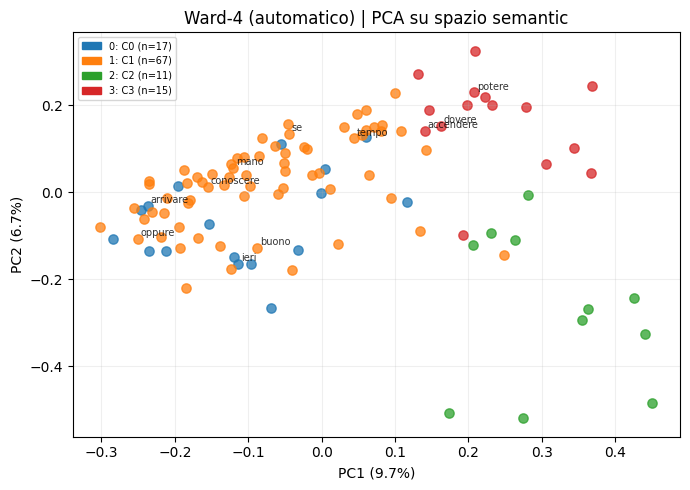

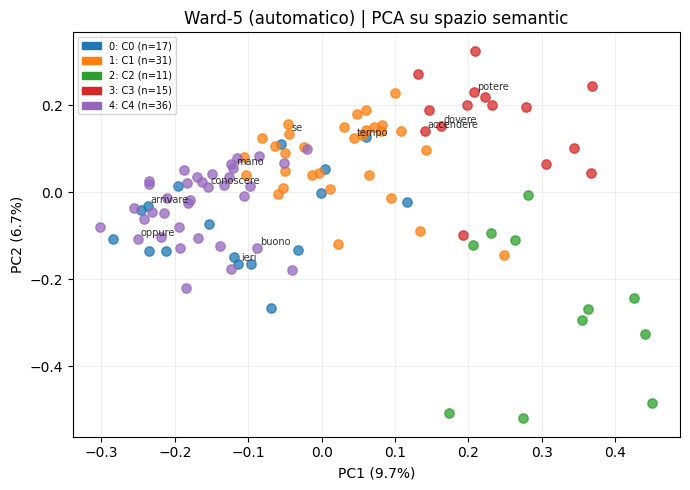

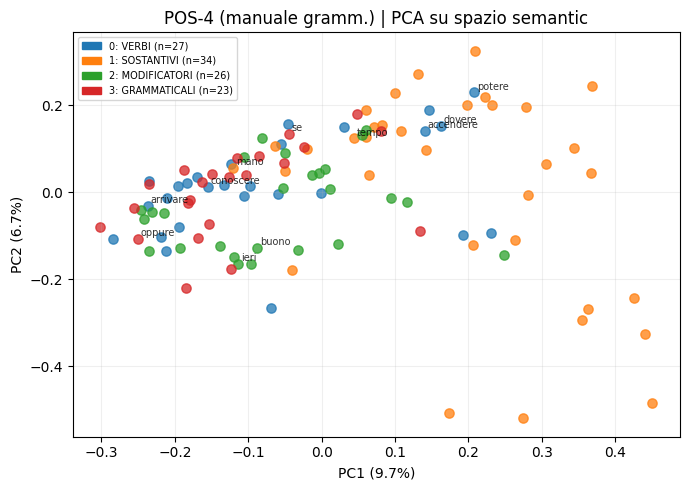

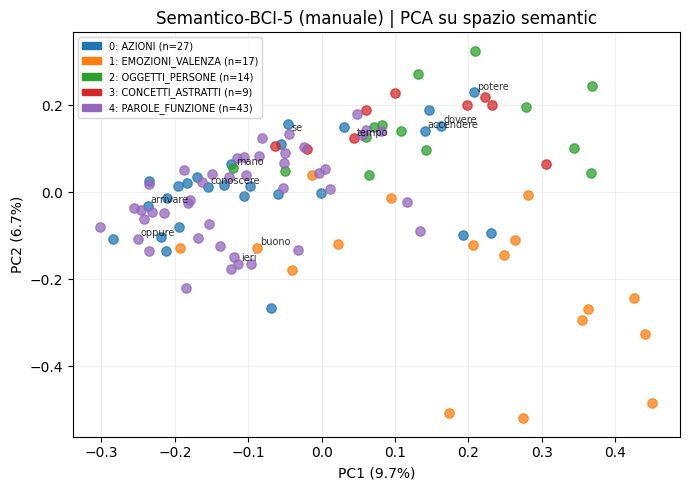

In [17]:
import matplotlib.patches as mpatches

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(emb)
var1, var2 = pca.explained_variance_ratio_

scheme_registry = [
    ("Ward-4 (automatico)", np.array([word2cluster_4[w] for w in true_labels]), ["C0","C1","C2","C3"], "semantic"),
    ("Ward-5 (automatico)", np.array([word2cluster_5[w] for w in true_labels]), ["C0","C1","C2","C3","C4"], "semantic"),
    ("POS-4 (manuale gramm.)", np.array([word2cluster_pos4[w] for w in true_labels]), cat_names_pos4, "semantic"),
    ("Semantico-BCI-5 (manuale)", np.array([word2cluster_sem5[w] for w in true_labels]), cat_names_sem5, "semantic"),
]

if word2cluster_psycho4 is not None:
    scheme_registry.append(("Psycho-4", np.array([word2cluster_psycho4[w] for w in true_labels]), ["C0","C1","C2","C3"], "psycho"))
if word2cluster_psycho5 is not None:
    scheme_registry.append(("Psycho-5", np.array([word2cluster_psycho5[w] for w in true_labels]), ["C0","C1","C2","C3","C4"], "psycho"))

cmap = plt.get_cmap("tab10")
annotate_idx = set(range(0, len(true_labels), ANNOTATE_EVERY))

for title, labels, cat_names, space_name in scheme_registry:
    plt.figure(figsize=(7, 5))
    patches = []
    for c in sorted(set(labels)):
        mask = labels == c
        color = cmap(c % 10)
        name = cat_names[c] if c < len(cat_names) else f"C{c}"
        plt.scatter(coords[mask, 0], coords[mask, 1], s=45, alpha=0.75, color=color)
        patches.append(mpatches.Patch(color=color, label=f"{c}: {name} (n={mask.sum()})"))

    for i, (w, x, y) in enumerate(zip(true_labels, coords[:, 0], coords[:, 1])):
        if i in annotate_idx:
            plt.annotate(w, (x, y), fontsize=7, alpha=0.8, xytext=(2, 2), textcoords="offset points")

    plt.title(f"{title} | PCA su spazio {space_name}")
    plt.xlabel(f"PC1 ({var1:.1%})")
    plt.ylabel(f"PC2 ({var2:.1%})")
    plt.legend(handles=patches, fontsize=7, framealpha=0.8)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    plt.close()


In [18]:
comparison_rows = []

for title, labels, _, space_name in scheme_registry:
    arr = np.asarray(labels)
    row = {"schema": title, "k": int(len(np.unique(arr))), "space": space_name}

    if len(np.unique(arr)) > 1:
        row["silhouette_semantic"] = float(silhouette_score(emb, arr))
        row["db_semantic"]         = float(davies_bouldin_score(emb, arr))
    else:
        row["silhouette_semantic"] = np.nan
        row["db_semantic"]         = np.nan

    comparison_rows.append(row)

# Schemi EEG: silhouette nello spazio EEG (non confrontabile con gli altri)
for schema_name, eeg_map, eeg_labels in [
    ("EEG-4 (ward)", word2cluster_eeg4, eeg_labels_4 if word2cluster_eeg4 is not None else None),
    ("EEG-5 (kmeans)", word2cluster_eeg5, eeg_labels_5 if word2cluster_eeg5 is not None else None),
]:
    if eeg_map is not None and eeg_prototypes is not None and eeg_labels is not None:
        sil_eeg = float(silhouette_score(eeg_prototypes, eeg_labels))
        db_eeg  = float(davies_bouldin_score(eeg_prototypes, eeg_labels))
        # silhouette semantica (proiezione delle stesse parole sugli embedding SBERT)
        # NOTE: solo parole con prototipo EEG disponibile
        valid_arr = np.array([eeg_map[w] for w in true_labels if w in eeg_map])
        emb_valid = emb[[i for i, w in enumerate(true_labels) if w in eeg_map]]
        sil_sem = float(silhouette_score(emb_valid, valid_arr)) if len(np.unique(valid_arr)) > 1 else np.nan
        comparison_rows.append({
            "schema": schema_name,
            "k": int(len(np.unique(eeg_labels))),
            "space": "eeg",
            "silhouette_semantic": round(sil_sem, 4),
            "db_semantic":         np.nan,
            "silhouette_eeg":      round(sil_eeg, 4),
            "db_eeg":              round(db_eeg, 4),
        })
    else:
        comparison_rows.append({
            "schema": schema_name, "k": 4 if "4" in schema_name else 5,
            "space": "eeg",
            "silhouette_semantic": np.nan, "db_semantic": np.nan,
            "silhouette_eeg": np.nan,      "db_eeg": np.nan,
        })

df_compare = (
    pd.DataFrame(comparison_rows)
    .fillna(np.nan)
    .sort_values(["space", "k", "schema"])
    .reset_index(drop=True)
)

# Formatta per display
print("╔══ CONFRONTO SCHEMI DI CLUSTERING ══╗")
print("  silhouette_semantic: quanto i cluster sono coerenti nello spazio SBERT")
print("  silhouette_eeg:      quanto i cluster sono coerenti nello spazio delle feature EEG")
print("  n/a = metrica non applicabile per quello spazio\n")
display(df_compare[["schema", "k", "space", "silhouette_semantic", "db_semantic",
                     "silhouette_eeg", "db_eeg"]].round(4))

print("\n─── Raccomandazione ───")
print("1) Ward-4 / Ward-5   → baseline semantica automatica (oggettiva)")
print("2) POS-4             → baseline linguistica pura (interpretabile)")
print("3) Semantico-BCI-5   → schema neuroscientificamente motivato (raccomandato)")
print("4) EEG-4 / EEG-5     → cluster derivati dal segnale (rilevante per BCI)")
print("   ↳ La silhouette_eeg misura la struttura *nei dati cerebrali*, non nel linguaggio.")
print("   ↳ Per il training, la metrica finale che conta è la test accuracy nel decoder.")

print("\n─── File salvati ───")
for f in sorted(interim_dir.glob("*.json")):
    print(f"  {f.name}")


╔══ CONFRONTO SCHEMI DI CLUSTERING ══╗
  silhouette_semantic: quanto i cluster sono coerenti nello spazio SBERT
  silhouette_eeg:      quanto i cluster sono coerenti nello spazio delle feature EEG
  n/a = metrica non applicabile per quello spazio



,schema,k,space,silhouette_semantic,db_semantic,silhouette_eeg,db_eeg
0,EEG-4 (ward),4,eeg,-0.0294,NaN,0.0990,2.5955
1,EEG-5 (kmeans),5,eeg,-0.0435,NaN,0.0684,2.4983
2,POS-4 (manuale gramm.),4,semantic,-0.0330,4.3866,NaN,NaN
3,Ward-4 (automatico),4,semantic,0.0769,2.9770,NaN,NaN
4,Semantico-BCI-5 (manuale),5,semantic,-0.0080,4.1620,NaN,NaN
5,Ward-5 (automatico),5,semantic,0.0260,3.1023,NaN,NaN



─── Raccomandazione ───
1) Ward-4 / Ward-5   → baseline semantica automatica (oggettiva)
2) POS-4             → baseline linguistica pura (interpretabile)
3) Semantico-BCI-5   → schema neuroscientificamente motivato (raccomandato)
4) EEG-4 / EEG-5     → cluster derivati dal segnale (rilevante per BCI)
   ↳ La silhouette_eeg misura la struttura *nei dati cerebrali*, non nel linguaggio.
   ↳ Per il training, la metrica finale che conta è la test accuracy nel decoder.

─── File salvati ───
  cluster_names_eeg_4.json
  cluster_names_eeg_5.json
  cluster_names_pos4.json
  cluster_names_sem5.json
  idx2label.json
  label2idx.json
  labelid2cluster_4.json
  labelid2cluster_5.json
  labelid2cluster_eeg_4.json
  labelid2cluster_eeg_5.json
  labelid2cluster_pos4.json
  labelid2cluster_sem5.json
  word2cluster_4.json
  word2cluster_5.json
  word2cluster_eeg_4.json
  word2cluster_eeg_5.json
  word2cluster_fine.json
  word2cluster_pos4.json
  word2cluster_sem5.json


---

## 13) EEG-driven clustering corretto: z-score per soggetto

### Perché il clustering EEG grezzo è soggetto-contaminato

Nel clustering EEG della Sezione 11 i prototipi vengono calcolati come media
di tutti i trial di tutti i soggetti. Il dataset è bilanciato (ogni parola ha
gli stessi 74 soggetti), quindi il *bias medio* di ogni soggetto si cancella
in teoria. In pratica però ε²=0.85 per soggetto vs ε²=0.03 per parola:
anche una piccola dipendenza residua dal soggetto domina il segnale parola.

### Soluzione: z-score per soggetto (StandardScaler per soggetto)

Per ogni soggetto `s`:
- normalizza ciascuna feature (canale × tipo) sottraendo la sua media e
  dividendo per la sua deviazione standard, calcolate **solo sui trial di s**

Questo rimuove sia il "DC offset" del soggetto sia le sue scale relative,
lasciando solo la struttura **intra-soggetto** (variazione da parola a parola).

> Referenza: Zhang et al. 2021 "Stratified normalization" (Frontiers in
> Neuroscience); confermata dalla letteratura sulla riduzione di variabilità
> inter-soggetto in EEG BCI.


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

SUBJ_DIR = project_root / "data" / "processed" / "subject_tensors" / "subject_tensors_aggregated_epoch"
subj_files = sorted([f for f in os.listdir(SUBJ_DIR) if f.endswith('.pt')])
print(f"Soggetti disponibili: {len(subj_files)}")

protos_z_list   = [[] for _ in range(110)]   # protos_z_list[w] = list of z-scored vectors
per_subj_protos = []                          # lista di array (110, 2360) — uno per soggetto

for subj_file in subj_files:
    try:
        d = torch.load(SUBJ_DIR / subj_file, map_location='cpu', weights_only=False)
        X_s = d['X'].numpy().reshape(len(d['X']), -1).astype(np.float32)  # (n_trials, 2360)
        y_s = d['y'].numpy().astype(int)

        # --- Z-score per soggetto: rimuove media e scala soggetto-specifica ---
        scaler = StandardScaler()
        X_z = scaler.fit_transform(X_s)

        for i, word_id in enumerate(y_s):
            protos_z_list[word_id].append(X_z[i])

        unique_words = np.unique(y_s)
        if len(unique_words) == 110:
            proto_s = np.vstack([X_z[y_s == w].mean(axis=0) for w in range(110)])
            per_subj_protos.append(proto_s)

        del d, X_s, X_z
    except Exception as e:
        print(f"  Errore {subj_file}: {e}")

gc.collect()

protos_z = np.vstack([
    np.vstack(protos_z_list[w]).mean(axis=0)
    for w in range(110) if protos_z_list[w]
]).astype(np.float32)
valid_ids_z = [w for w in range(110) if protos_z_list[w]]
del protos_z_list
gc.collect()

print(f"Prototipi z-scored: {protos_z.shape}  |  soggetti con tutti i 110 words: {len(per_subj_protos)}")


Soggetti disponibili: 74


Prototipi z-scored: (110, 2360)  |  soggetti con tutti i 110 words: 74


In [20]:
from sklearn.decomposition import PCA as PCA_sk

# PCA: riduzione dimensionale prima del clustering
# Motivazione: le 2360 feature sono fortemente correlate (feature spettrali
# adiacenti, canali vicini). La PCA rimuove ridondanza e accelera UMAP.
pca_z = PCA_sk(n_components=50, random_state=RANDOM_STATE)
protos_z_pca = pca_z.fit_transform(protos_z)
print(f"PCA (50 PC): varianza spiegata = {pca_z.explained_variance_ratio_.sum():.1%}")

# Clustering Ward-4 e KMeans-5 sui prototipi z-scored + PCA
eeg_z_labels_4 = fcluster(linkage(protos_z_pca, method='ward'), t=4, criterion='maxclust') - 1
km5_z = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
eeg_z_labels_5 = km5_z.fit_predict(protos_z_pca)

word2cluster_eeg_z4, _, _ = save_word_cluster_mapping(valid_ids_z, eeg_z_labels_4, 'eeg_z4', n_cls=4)
word2cluster_eeg_z5, _, _ = save_word_cluster_mapping(valid_ids_z, eeg_z_labels_5, 'eeg_z5', n_cls=5)

sil_z4 = silhouette_score(protos_z_pca, eeg_z_labels_4)
sil_z5 = silhouette_score(protos_z_pca, eeg_z_labels_5)
print(f"silhouette EEG-z4 (Ward):   {sil_z4:.4f}")
print(f"silhouette EEG-z5 (KMeans): {sil_z5:.4f}")
print(f"  (confronto: EEG grezzo ward-4 = 0.099)")

print("\n=== CLUSTER EEG-z4 (z-score per soggetto + PCA + Ward) ===")
cls2w_z4 = defaultdict(list)
for wid, cid in zip(valid_ids_z, eeg_z_labels_4):
    cls2w_z4[cid].append(idx2label[wid])
for c in sorted(cls2w_z4):
    print(f"  C{c} (n={len(cls2w_z4[c])}): {', '.join(sorted(cls2w_z4[c]))}")

print("\n=== CLUSTER EEG-z5 (z-score per soggetto + PCA + KMeans) ===")
cls2w_z5 = defaultdict(list)
for wid, cid in zip(valid_ids_z, eeg_z_labels_5):
    cls2w_z5[cid].append(idx2label[wid])
for c in sorted(cls2w_z5):
    print(f"  C{c} (n={len(cls2w_z5[c])}): {', '.join(sorted(cls2w_z5[c]))}")


PCA (50 PC): varianza spiegata = 74.8%
silhouette EEG-z4 (Ward):   0.0315
silhouette EEG-z5 (KMeans): 0.0309
  (confronto: EEG grezzo ward-4 = 0.099)

=== CLUSTER EEG-z4 (z-score per soggetto + PCA + Ward) ===
  C0 (n=45): accendere, acqua, adesso, andare, anno, ansia, arrivare, aspettare, avanti, bello, bisogno, casa, chiamare, destra, dire, dolore, domanda, dovere, essere, felicità, forse, gioia, grande, indietro, loro, male, mettere, molto, morte, noi, oggetto, perchè, persona, piccolo, più, potere, prendere, quindi, riposo, se, sentire, serenità, telefono, tristezza, vecchio
  C1 (n=9): aiuto, chiudere, fare, lei, no, oppure, sapere, sempre, tempo
  C2 (n=13): anche, cibo, computer, conoscere, gruppo, idea, lui, poco, quando, questo, sinistra, sotto, uomo
  C3 (n=43): amore, aprire, avere, bagno, bene, bere, brutto, buono, capire, cattivo, chiedere, come, cosa, dare, domani, donna, dove, guerra, ieri, io, lavoro, macchina, mangiare, mano, mille, nuovo, oggi, parte, paura, però, poi

---

## 14) UMAP + HDBSCAN — cluster senza k fisso

Forzare k=4 o k=5 è arbitrario. **UMAP** proietta i 110 prototipi z-scored
in 2D preservando la struttura locale e globale, poi **HDBSCAN** trova cluster
a densità variabile senza dover specificare il numero.

**Perché UMAP invece di t-SNE?**

| | PCA | t-SNE | UMAP |
|--|--|--|--|
| Struttura globale | ✓ | ✗ | Parziale |
| Struttura locale | ✗ | ✓ | ✓ |
| Metrica preservata | ✓ | ✗ | ✓ |
| Usabile per clustering downstream | ✓ | ✗ | ✓ |
| Velocità | Veloce | Lento | Veloce |

t-SNE non produce distanze significative fuori dal vicinato locale → non
si può fare clustering affidabile. UMAP preserva una metrica, quindi
HDBSCAN produce cluster defensibili.

> Referenza: Krumm et al. 2025 (Annals of Neurology) usa esattamente
> questa pipeline per costruire una mappa semantica dell'EEG.
> McInnes et al. 2018 UMAP; Campello et al. 2013 HDBSCAN.


/opt/homebrew/Caskroom/miniconda/base/envs/daniele_311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP fit completato. Shape: (110, 2)
HDBSCAN: 2 cluster trovati  |  6 parole non assegnate (noise)
  Parole noise riassegnate al cluster più vicino.
silhouette HDBSCAN (spazio UMAP): 0.5928

=== CLUSTER HDBSCAN (k=2) ===
  C0 (n=54): aiuto, amore, aprire, avanti, bagno, bene, bere, bisogno, brutto, buono, capire, cattivo, chiudere, cibo, conoscere, cosa, dare, domani, dove, fare, gruppo, guerra, idea, ieri, io, lavoro, lei, lui, macchina, mangiare, mano, mille, no, oggi, oppure, parte, paura, però, poi, prima, problema, quando, sapere, sempre, si, sinistra, sopra, sotto, tempo, tristezza, trovare, uno, venire, volere
  C1 (n=56): accendere, acqua, adesso, anche, andare, anno, ansia, arrivare, aspettare, avere, bello, casa, chiamare, chiedere, come, computer, destra, dire, dolore, domanda, donna, dovere, essere, felicità, forse, gioia, grande, indietro, loro, male, mettere, molto, morte, noi, nuovo, oggetto, perchè, persona, piccolo, più, poco, potere, prendere, quello, questo, quindi, 

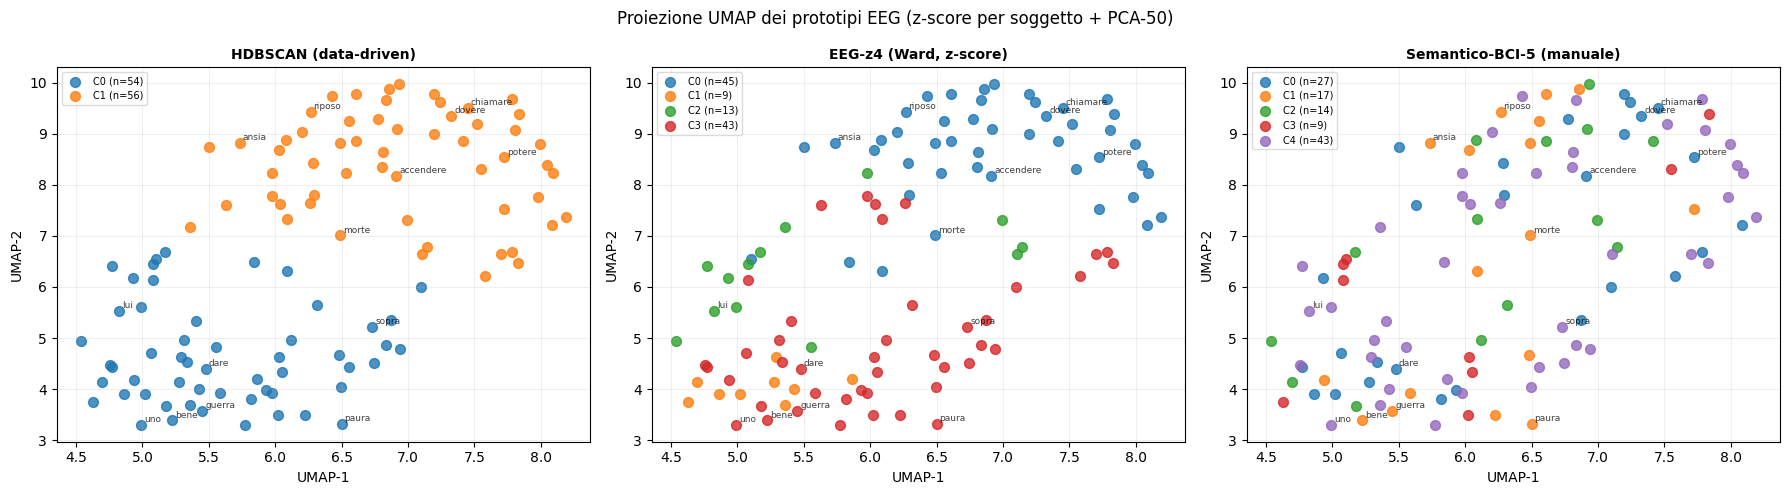

In [21]:
import umap
import hdbscan
import matplotlib.patches as mpatches

# --- UMAP 2D sui prototipi z-scored + PCA ---
# n_neighbors: scala della struttura locale da preservare
# min_dist: compattezza dei cluster nella proiezione
# metric: cosine per feature normalizzate (ignora scale assolute)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE,
    n_components=2,
    verbose=False,
)
coords_umap = reducer.fit_transform(protos_z_pca)  # (110, 2)
print("UMAP fit completato. Shape:", coords_umap.shape)

# --- HDBSCAN: clustering a densità senza k fisso ---
# min_cluster_size: dimensione minima di un cluster (8-10 per 110 parole)
# min_samples: robustezza al rumore (>1 = più conservativo)
clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
hdb_labels = clusterer.fit_predict(coords_umap)    # -1 = noise/non-assegnato

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
print(f"HDBSCAN: {n_clusters_hdb} cluster trovati  |  {n_noise} parole non assegnate (noise)")

# Salva se almeno 2 cluster trovati
if n_clusters_hdb >= 2:
    # riassegna noise al cluster più vicino (centroide) per uso pratico
    hdb_labels_clean = hdb_labels.copy()
    if n_noise > 0:
        for i in np.where(hdb_labels == -1)[0]:
            dists = [np.linalg.norm(coords_umap[i] - coords_umap[hdb_labels == c].mean(axis=0))
                     for c in range(n_clusters_hdb)]
            hdb_labels_clean[i] = int(np.argmin(dists))
        print(f"  Parole noise riassegnate al cluster più vicino.")

    word2cluster_hdb, _, _ = save_word_cluster_mapping(
        valid_ids_z, hdb_labels_clean, f'eeg_hdb{n_clusters_hdb}', n_cls=n_clusters_hdb
    )
    sil_hdb = silhouette_score(coords_umap, hdb_labels_clean)
    print(f"silhouette HDBSCAN (spazio UMAP): {sil_hdb:.4f}")

    print(f"\n=== CLUSTER HDBSCAN (k={n_clusters_hdb}) ===")
    cls2w_hdb = defaultdict(list)
    for wid, cid in zip(valid_ids_z, hdb_labels_clean):
        cls2w_hdb[cid].append(idx2label[wid])
    for c in sorted(cls2w_hdb):
        lbl = "noise→riassegnato" if c == -1 else f"C{c}"
        print(f"  {lbl} (n={len(cls2w_hdb[c])}): {', '.join(sorted(cls2w_hdb[c]))}")
else:
    print("HDBSCAN: struttura insufficiente per formare cluster (tutto noise o 1 cluster).")
    print("Questo è un risultato informativo: suggerisce che i prototipi EEG")
    print("non formano cluster naturali a densità elevata nello spazio UMAP.")
    word2cluster_hdb = None
    hdb_labels_clean = None

# --- Visualizzazione UMAP: confronto schemi ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.get_cmap('tab10')

schemes_umap = [
    ("HDBSCAN (data-driven)", hdb_labels_clean if hdb_labels_clean is not None else eeg_z_labels_4,
     n_clusters_hdb if n_clusters_hdb >= 2 else 4),
    ("EEG-z4 (Ward, z-score)", eeg_z_labels_4, 4),
    ("Semantico-BCI-5 (manuale)", np.array([word2cluster_sem5[w] for w in [idx2label[v] for v in valid_ids_z]]), 5),
]

for ax, (title, labels, k) in zip(axes, schemes_umap):
    for c in sorted(set(labels)):
        mask = np.array(labels) == c
        ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
                   color=cmap(c % 10), s=50, alpha=0.8, label=f"C{c} (n={mask.sum()})")
    for i, wid in enumerate(valid_ids_z):
        if i % 8 == 0:
            ax.annotate(idx2label[wid], coords_umap[i], fontsize=6.5, alpha=0.75,
                        xytext=(2, 2), textcoords='offset points')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, framealpha=0.7)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)

plt.suptitle("Proiezione UMAP dei prototipi EEG (z-score per soggetto + PCA-50)", fontsize=12)
plt.tight_layout()
plt.show()
plt.close()


---

## 15) RSA — Representational Similarity Analysis

**RSA** confronta la geometria dello spazio EEG con la geometria dello spazio
semantico senza fare decoding. Si costruiscono due **Representational
Dissimilarity Matrices (RDM)** — matrici 110×110 di distanze a coppie:

- **RDM_EEG**: distanza coseno tra i prototipi z-scored di ogni parola
- **RDM_SEM**: distanza coseno tra gli embedding SBERT di ogni parola

Se il segnale EEG contiene struttura semantica, le due RDM devono essere
correlate (test di Mantel con permutazione).

**Interpretazione:**
- r ≈ 0: l'EEG non rispecchia la struttura semantica
- r > 0.1 e p < 0.05: correlazione debole ma statisticamente significativa
- r > 0.3: correlazione moderata (interessante per la tesi)

> Referenza: King et al. iScience 2024 (PubMed 39524349) — usa RSA per
> dimostrare che l'EEG traccia l'elaborazione semantica implicita.
> È lo strumento standard per collegare rappresentazioni neurali a modelli
> computazionali senza training supervisionato.


═══ RSA: EEG RDM vs. Semantico SBERT RDM ═══
  Pearson  r = 0.0010   p = 9.3553e-01
  Spearman r = 0.0037   p = 7.7199e-01
  n coppie = 5995



  Permutation test (1000 permutazioni):
  p-perm = 0.8170  (distribuzione null: mean=-0.0004, std=0.0048)

Interpretazione:
  → r ≈ 0 o non significativo: la geometria EEG non rispecchia quella semantica.
    Questo è atteso per feature spettrali aggregate con alta variabilità inter-soggetto.
    Suggerisce che serve un modello DL per estrarre rappresentazioni semanticamente organizzate.


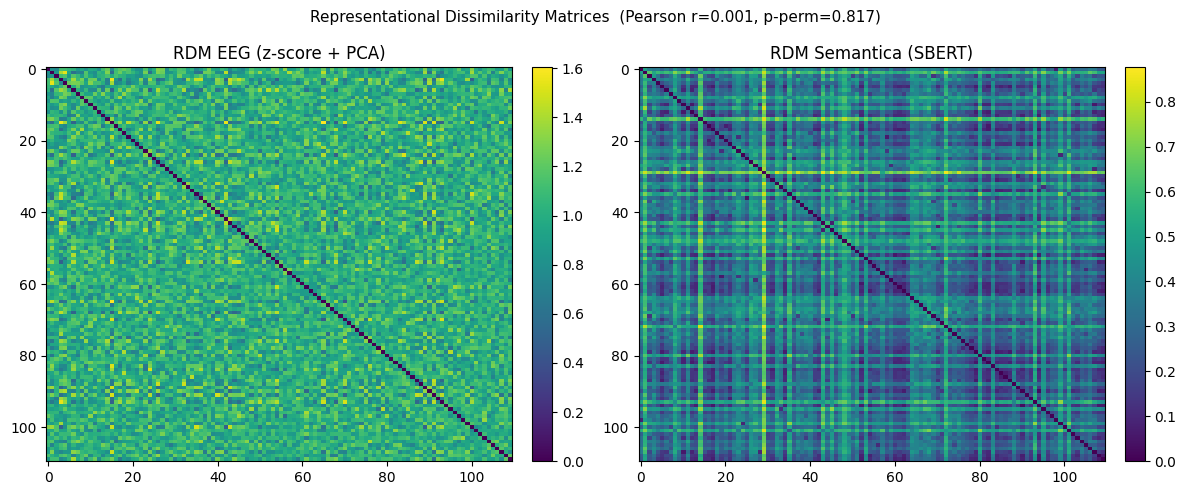

In [22]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

def rdm_cosine(X):
    """Representational Dissimilarity Matrix: 1 - cosine_similarity."""
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-10
    X_n = X / norms
    sim = X_n @ X_n.T                  # cosine similarity (n × n)
    return 1.0 - sim                    # dissimilarity

# RDM EEG (prototipi z-scored + PCA)
rdm_eeg = rdm_cosine(protos_z_pca)     # (110, 110)

# RDM semantica (embedding SBERT, già in memoria come `emb`)
# Gli indici corrispondono all'ordine di true_labels
# valid_ids_z potrebbe non coprire tutti i 110 — allineiamo
rdm_sem_full = rdm_cosine(emb)          # (110, 110)
rdm_sem = rdm_sem_full[np.ix_(valid_ids_z, valid_ids_z)]  # solo parole con prototipo EEG

# Estrai triangolo superiore (esclude diagonale)
n = len(valid_ids_z)
triu_idx = np.triu_indices(n, k=1)
vec_eeg = rdm_eeg[triu_idx]
vec_sem = rdm_sem[triu_idx]

# Test di Mantel: correlazione di Pearson + permutazione
r_pearson, p_pearson = pearsonr(vec_eeg, vec_sem)
r_spearman, p_spearman = spearmanr(vec_eeg, vec_sem)

print("═══ RSA: EEG RDM vs. Semantico SBERT RDM ═══")
print(f"  Pearson  r = {r_pearson:.4f}   p = {p_pearson:.4e}")
print(f"  Spearman r = {r_spearman:.4f}   p = {p_spearman:.4e}")
print(f"  n coppie = {len(vec_eeg)}")

# Permutation test (più rigoroso di p-value analitico per dati non-iid)
N_PERM = 1000
perm_rs = []
rng = np.random.default_rng(RANDOM_STATE)
for _ in range(N_PERM):
    perm = rng.permutation(n)
    rdm_eeg_perm = rdm_eeg[np.ix_(perm, perm)]
    r_p, _ = pearsonr(rdm_eeg_perm[triu_idx], vec_sem)
    perm_rs.append(r_p)

p_perm = np.mean(np.abs(perm_rs) >= np.abs(r_pearson))
print(f"\n  Permutation test ({N_PERM} permutazioni):")
print(f"  p-perm = {p_perm:.4f}  (distribuzione null: mean={np.mean(perm_rs):.4f}, std={np.std(perm_rs):.4f})")

print("\nInterpretazione:")
if abs(r_pearson) < 0.05 or p_perm > 0.05:
    print("  → r ≈ 0 o non significativo: la geometria EEG non rispecchia quella semantica.")
    print("    Questo è atteso per feature spettrali aggregate con alta variabilità inter-soggetto.")
    print("    Suggerisce che serve un modello DL per estrarre rappresentazioni semanticamente organizzate.")
elif abs(r_pearson) < 0.15:
    print(f"  → Correlazione debole (r={r_pearson:.3f}) ma significativa: traccia di struttura semantica.")
    print("    Fondamento per aspettarsi che un modello DL possa amplificare questo segnale.")
else:
    print(f"  → Correlazione moderata (r={r_pearson:.3f}): la geometria EEG rispecchia parzialmente")
    print("    quella semantica. Questo è un risultato positivo per il decoding.")

# Visualizzazione RDM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(rdm_eeg, aspect='auto', cmap='viridis')
axes[0].set_title("RDM EEG (z-score + PCA)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(rdm_sem, aspect='auto', cmap='viridis')
axes[1].set_title("RDM Semantica (SBERT)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle(f"Representational Dissimilarity Matrices  (Pearson r={r_pearson:.3f}, p-perm={p_perm:.3f})", fontsize=11)
plt.tight_layout()
plt.show()
plt.close()


---

## 16) Stabilità cross-soggetto — ARI e NMI

Per ogni soggetto, calcoliamo i prototipi z-scored e poi li clusterizziamo
indipendentemente (Ward-4). Confrontiamo i cluster assignment tra tutte le
coppie di soggetti con **ARI** (Adjusted Rand Index) e **NMI** (Normalized
Mutual Information).

**Interpretazione:**
- ARI = 0: assignment casuale, i cluster dei due soggetti non concordano
- ARI > 0.1: struttura replicabile (debole ma non casuale)
- ARI > 0.3: concordanza moderata → il clustering cattura qualcosa di reale

Questo risponde direttamente alla domanda: *"il clustering EEG riflette
struttura genuina (parola-specifica) o rumore soggetto-specifico?"*

Se l'ARI cross-soggetto è vicino a 0, il clustering è instabile → dipende
dal soggetto, non dalla parola. Se è significativamente > 0, c'è una struttura
condivisa tra soggetti.

> Referenza: Rosner et al. Brain Topography 2024 — consensus clustering per
> EEG con valutazione di stabilità multi-soggetto.


Clustering per-soggetto calcolato su 74 soggetti



═══ Stabilità cross-soggetto (Ward-4, z-score + PCA-50) ═══
  Metrica       Media      Std  Mediana      Min      Max
  ────────────────────────────────────────────────────
  ARI         -0.0001   0.0179  -0.0024  -0.0564   0.1156
  NMI          0.0002   0.0172  -0.0023  -0.0394   0.0639

  Permutation test: ARI medio reale=-0.0001 vs null mean=-0.0020  p=1.0000


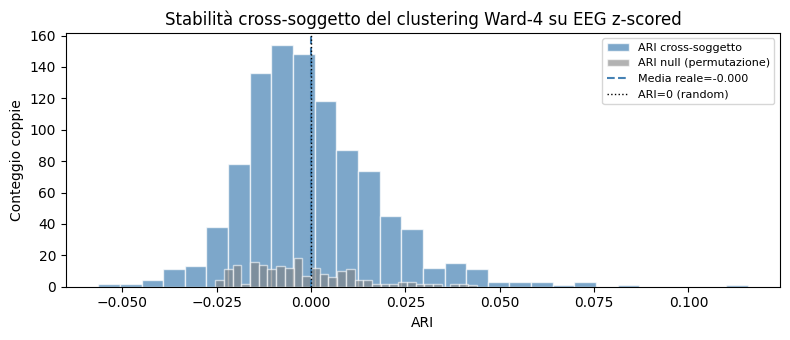


Interpretazione:
  → ARI ≈ 0: il clustering Ward-4 è instabile cross-soggetto.
    La struttura di ogni soggetto è diversa → dominanza soggetto-specifica.
    Questo conferma che lo schema EEG-z4 non è generalizzabile.


In [23]:
import random as _random

# Per ogni soggetto: PCA → Ward-4 indipendente
per_subj_ward4 = []
pca_stab = PCA_sk(n_components=50, random_state=RANDOM_STATE)

# Fit PCA sul pool globale (usiamo protos_z_pca già calcolata come riferimento)
# Per ogni soggetto applichiamo la stessa PCA globale per confrontabilità
for proto_s in per_subj_protos:   # (n_valid_subj, 110, 2360)
    proto_s_pca = pca_z.transform(proto_s)  # usa la PCA globale già fittata
    labels_s = fcluster(linkage(proto_s_pca, method='ward'), t=4, criterion='maxclust') - 1
    per_subj_ward4.append(labels_s)

n_subj_stab = len(per_subj_ward4)
print(f"Clustering per-soggetto calcolato su {n_subj_stab} soggetti")

# Campiona coppie di soggetti per il calcolo di ARI/NMI
_random.seed(RANDOM_STATE)
all_pairs = [(i, j) for i in range(n_subj_stab) for j in range(i + 1, n_subj_stab)]
sampled_pairs = _random.sample(all_pairs, k=min(1000, len(all_pairs)))

aris  = [adjusted_rand_score(per_subj_ward4[i], per_subj_ward4[j])       for i, j in sampled_pairs]
nmis  = [adjusted_mutual_info_score(per_subj_ward4[i], per_subj_ward4[j]) for i, j in sampled_pairs]

print("\n═══ Stabilità cross-soggetto (Ward-4, z-score + PCA-50) ═══")
print(f"  {'Metrica':<10} {'Media':>8} {'Std':>8} {'Mediana':>8} {'Min':>8} {'Max':>8}")
print("  " + "─" * 52)
print(f"  {'ARI':<10} {np.mean(aris):>8.4f} {np.std(aris):>8.4f} {np.median(aris):>8.4f} {np.min(aris):>8.4f} {np.max(aris):>8.4f}")
print(f"  {'NMI':<10} {np.mean(nmis):>8.4f} {np.std(nmis):>8.4f} {np.median(nmis):>8.4f} {np.min(nmis):>8.4f} {np.max(nmis):>8.4f}")

# Confronto con baseline random (permutazione)
n_perm_stab = 200
aris_null = [
    adjusted_rand_score(
        per_subj_ward4[0],
        np.random.default_rng(seed).permutation(per_subj_ward4[1])
    )
    for seed in range(n_perm_stab)
]
p_stab = np.mean(np.abs(aris_null) >= np.abs(np.mean(aris)))
print(f"\n  Permutation test: ARI medio reale={np.mean(aris):.4f} vs null mean={np.mean(aris_null):.4f}  p={p_stab:.4f}")

# --- Visualizzazione distribuzione ARI ---
plt.figure(figsize=(8, 3.5))
plt.hist(aris, bins=30, alpha=0.7, label='ARI cross-soggetto', color='steelblue', edgecolor='white')
plt.hist(aris_null, bins=30, alpha=0.6, label='ARI null (permutazione)', color='gray', edgecolor='white')
plt.axvline(np.mean(aris), color='steelblue', linestyle='--', linewidth=1.5, label=f'Media reale={np.mean(aris):.3f}')
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='ARI=0 (random)')
plt.xlabel("ARI"); plt.ylabel("Conteggio coppie")
plt.title("Stabilità cross-soggetto del clustering Ward-4 su EEG z-scored")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

print("\nInterpretazione:")
mean_ari = np.mean(aris)
if mean_ari < 0.03:
    print("  → ARI ≈ 0: il clustering Ward-4 è instabile cross-soggetto.")
    print("    La struttura di ogni soggetto è diversa → dominanza soggetto-specifica.")
    print("    Questo conferma che lo schema EEG-z4 non è generalizzabile.")
elif mean_ari < 0.10:
    print(f"  → ARI debole ({mean_ari:.3f}): struttura lievemente stabile ma fragile.")
    print("    Usare come hint, non come partizione definitiva.")
else:
    print(f"  → ARI moderato ({mean_ari:.3f}): struttura replicabile cross-soggetto.")
    print("    Il clustering cattura qualcosa di genuinamente parola-specifico.")
